# Hybrid LSTM + K-Means — Final Production Notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input,
                                      Concatenate)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              silhouette_score, r2_score)
import joblib, warnings, json
from pathlib import Path

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)
print('Pandas:', pd.__version__)

TensorFlow: 2.15.0
Pandas: 2.3.3


## 1. Load Data

In [2]:
df = pd.read_csv('../data/cleaned_data_enriched.csv')
print('Raw shape:', df.shape)
print('Households:', df['household_id'].nunique())
print('Columns:', df.columns.tolist())
print()
print(df[['household_id','month','monthly_kwh','target']].head(5).to_string())

Raw shape: (15105, 27)
Households: 1438
Columns: ['household_id', 'month', 'monthly_kwh', 'prev1', 'prev2', 'prev3', 'target', 'peak_ratio', 'family_size', 'has_refrigerator', 'has_ac', 'has_geyser', 'has_electric_cooking', 'has_washing_machine', 'has_water_pump', 'work_from_home', 'no_members_wfh', 'avg_hours_wfh', 'temp', 'humidity', 'rain', 'inverter_ac', 'non_inverter_ac', 'has_solar', 'water_heater_solar', 'led_ratio', 'ac_hours_per_day']

  household_id  month  monthly_kwh   target
0       ID0013      3      294.139  175.646
1       ID0013      4      175.646  149.361
2       ID0013      5      168.025  149.978
3       ID0013      6      168.842  164.528
4       ID0013      7      156.287  159.222


In [3]:
print(df.columns)

Index(['household_id', 'month', 'monthly_kwh', 'prev1', 'prev2', 'prev3',
       'target', 'peak_ratio', 'family_size', 'has_refrigerator', 'has_ac',
       'has_geyser', 'has_electric_cooking', 'has_washing_machine',
       'has_water_pump', 'work_from_home', 'no_members_wfh', 'avg_hours_wfh',
       'temp', 'humidity', 'rain', 'inverter_ac', 'non_inverter_ac',
       'has_solar', 'water_heater_solar', 'led_ratio', 'ac_hours_per_day'],
      dtype='object')


## 2. Data Cleaning

**Bug 1 fix:** The previous notebook clipped at > 400 kWh. This removed 1,784
perfectly valid rows — a household using 250–400 kWh/month is normal.

The only rows that need removing are:
- 14 households with data entry errors (values in the millions)
- 1 commercial-scale household (ID3624, median > 1,000 kWh)
- Single-row spikes where `target > 4× that household's mean`
- Near-zero targets (missing next-month records)

In [4]:
# Stage A: Remove households with IMPOSSIBLE values (>400 kWh = data error)
corrupt_mask = (
    (df['monthly_kwh'] > 400) | (df['target'] > 400)
)
corrupt_hh_A = set(df[corrupt_mask]['household_id'].unique())
print(f'Stage A — corrupt households (>400 kWh): {len(corrupt_hh_A)}')
print(f'  IDs: {sorted(corrupt_hh_A)}')

# Stage B: Commercial-scale (median monthly > 1000 kWh)
hh_median = df.groupby('household_id')['monthly_kwh'].median()
corrupt_hh_B = set(hh_median[hh_median > 1000].index)
print(f'Stage B — commercial households (median>1000 kWh): {len(corrupt_hh_B)}')
if corrupt_hh_B:
    print(f'  IDs: {sorted(corrupt_hh_B)}')

all_corrupt = corrupt_hh_A | corrupt_hh_B
df1 = df[~df['household_id'].isin(all_corrupt)].copy()

# Stage C: Single-row spikes (target > 4× household mean)
hh_mean_t = df1.groupby('household_id')['target'].mean().rename('hh_mean')
df1 = df1.merge(hh_mean_t, on='household_id')
spike_mask = df1['target'] > df1['hh_mean'] * 4
print(f'Stage C — single-row spikes: {spike_mask.sum()} rows removed')
df1 = df1[~spike_mask].drop(columns=['hh_mean'])

# Stage D: Near-zero targets
before = len(df1)
df1 = df1[(df1['target'] >= 5) & (df1['monthly_kwh'] >= 5)].copy()
print(f'Stage D — near-zero targets: {before - len(df1)} rows removed')

df1 = df1.reset_index(drop=True)
print()
print(f'Final clean shape: {df1.shape}')
print(f'Final households:  {df1["household_id"].nunique()}')
print()
print('target distribution:')
print(df1['target'].describe().round(1).to_string())

Stage A — corrupt households (>400 kWh): 128
  IDs: ['ID0018', 'ID0043', 'ID0066', 'ID0127', 'ID0154', 'ID0177', 'ID0189', 'ID0198', 'ID0210', 'ID0246', 'ID0250', 'ID0264', 'ID0276', 'ID0296', 'ID0381', 'ID0417', 'ID0457', 'ID0544', 'ID0545', 'ID0551', 'ID0555', 'ID0558', 'ID0596', 'ID0600', 'ID0671', 'ID0733', 'ID0741', 'ID0772', 'ID0781', 'ID0796', 'ID0841', 'ID0844', 'ID0954', 'ID0987', 'ID1009', 'ID1028', 'ID1051', 'ID1097', 'ID1127', 'ID1132', 'ID1165', 'ID1184', 'ID1251', 'ID1284', 'ID1290', 'ID1377', 'ID1400', 'ID1496', 'ID1510', 'ID1581', 'ID1625', 'ID1653', 'ID1659', 'ID1672', 'ID1680', 'ID1683', 'ID1721', 'ID1743', 'ID1751', 'ID1762', 'ID1771', 'ID1777', 'ID1781', 'ID1978', 'ID1985', 'ID1992', 'ID2027', 'ID2042', 'ID2167', 'ID2194', 'ID2220', 'ID2221', 'ID2223', 'ID2278', 'ID2312', 'ID2323', 'ID2391', 'ID2420', 'ID2422', 'ID2440', 'ID2486', 'ID2584', 'ID2588', 'ID2616', 'ID2632', 'ID2660', 'ID2747', 'ID2770', 'ID2774', 'ID2781', 'ID2923', 'ID3029', 'ID3058', 'ID3063', 'ID3066

## 3. Feature Engineering

This version keeps monthly sequence features for LSTM and uses a compact behavior vector.

Behavior features are now:
- `ac_usage = has_ac * ac_hours_per_day`
- `wfh_impact = avg_hours_wfh * family_size`
- `energy_intensity = monthly_kwh / family_size`
- `ac_fraction = ac_usage / monthly_kwh`

Weather columns may exist in the dataset, but they are not used in model training.

In [5]:
df1 = df1.sort_values(['household_id', 'month']).reset_index(drop=True)

# Lag features: past monthly kWh values for the same household.
# These are safe because they only use earlier months within each household.
df1['lag_1'] = df1.groupby('household_id')['monthly_kwh'].shift(1)
df1['lag_2'] = df1.groupby('household_id')['monthly_kwh'].shift(2)
df1['lag_3'] = df1.groupby('household_id')['monthly_kwh'].shift(3)
df1[['lag_1', 'lag_2', 'lag_3']] = df1[['lag_1', 'lag_2', 'lag_3']].fillna(0)

# Required columns for engineered behavior features.
required_base_cols = ['has_ac', 'ac_hours_per_day', 'avg_hours_wfh', 'family_size', 'monthly_kwh']
missing_base = [c for c in required_base_cols if c not in df1.columns]
if missing_base:
    raise ValueError(f'Missing required columns for engineered behavior features: {missing_base}')

# Engineered behavior features requested.
df1['ac_usage'] = df1['has_ac'] * df1['ac_hours_per_day']
df1['wfh_impact'] = df1['avg_hours_wfh'] * df1['family_size']
family_size_safe = df1['family_size'].replace(0, np.nan)
df1['energy_intensity'] = (df1['monthly_kwh'] / family_size_safe).replace([np.inf, -np.inf], np.nan)

# NEW STRONG FEATURE: fraction of monthly kWh attributable to AC (ac_usage / monthly_kwh)
# This often explains large parts of household consumption variation where AC is present.
df1['ac_fraction'] = 0.0
if 'ac_usage' in df1.columns:
    df1['ac_fraction'] = df1['ac_usage'] / df1['monthly_kwh'].replace(0, np.nan)
# Replace infinities and NaNs produced by zero monthly_kwh
df1['ac_fraction'] = df1['ac_fraction'].replace([np.inf, -np.inf], 0).fillna(0)

# Fill any NaN generated by zero family size or upstream missing values.
df1['energy_intensity'] = df1['energy_intensity'].fillna(0)

print('Feature engineering done. Shape:', df1.shape)
print()
check_cols = ['monthly_kwh', 'month', 'lag_1', 'lag_2', 'lag_3', 'ac_usage', 'wfh_impact', 'energy_intensity', 'ac_fraction']
nan_counts = df1[check_cols].isnull().sum()
if nan_counts.sum() == 0:
    print('NaN check: PASS - zero NaN in core model input columns')
else:
    print('NaN check: FAIL')
    print(nan_counts[nan_counts > 0])

# Global clean
df1.replace([np.inf, -np.inf], 0, inplace=True)
df1.fillna(0, inplace=True)

Feature engineering done. Shape: (13090, 34)

NaN check: PASS - zero NaN in core model input columns


## 4. Define Feature Sets

Time branch: monthly sequence using `monthly_kwh`, `month`, and lagged kWh features.

Behavior branch: engineered behavior features only.
Weather features are explicitly excluded from model training.

In [ ]:
# ================================
# TIME + BEHAVIOR FEATURES
# ================================
TIME_FEATURES = [
    'monthly_kwh',
    'month',
    'lag_1',
    'lag_2',
    'lag_3',
]

ENGINEERED_BEHAVIOR_FEATURES = [
    'ac_usage',
    'wfh_impact',
    'energy_intensity',
    'ac_fraction',
]

# Weather features are intentionally excluded from model training.
WEATHER_CANDIDATES = [
    'temp',
    'humidity',
    'rainfall',
    'wind_speed',
]
WEATHER_FEATURES = [c for c in WEATHER_CANDIDATES if c in df1.columns]

BEHAVIOR_FEATURES = ENGINEERED_BEHAVIOR_FEATURES

missing_behavior = [c for c in BEHAVIOR_FEATURES if c not in df1.columns]
if missing_behavior:
    raise ValueError(f'Missing behavior features in df1: {missing_behavior}')

missing_time = [c for c in TIME_FEATURES if c not in df1.columns]
if missing_time:
    raise ValueError(f'Missing time features in df1: {missing_time}')

ALL_FEATURES = TIME_FEATURES + BEHAVIOR_FEATURES
TIME_SCALE_FEATURE_IDXS = [0, 2, 3, 4]
TIME_FEATURE_WEIGHTS = {
    'monthly_kwh': 1.25,
    'month': 0.90,
    'lag_1': 1.35,
    'lag_2': 1.15,
    'lag_3': 1.10,
}

def apply_time_feature_weights(time_array):
    weighted = time_array.copy()
    for idx, feature_name in enumerate(TIME_FEATURES):
        weighted[:, :, idx] *= TIME_FEATURE_WEIGHTS.get(feature_name, 1.0)
    return weighted

print(f'TIME_FEATURES: {len(TIME_FEATURES)} -> {TIME_FEATURES}')
print('  (Using raw month index plus lagged kWh history for the time branch)')
print(f'ENGINEERED_BEHAVIOR_FEATURES: {len(ENGINEERED_BEHAVIOR_FEATURES)} -> {ENGINEERED_BEHAVIOR_FEATURES}')
print(f'WEATHER_FEATURES_FOUND_BUT_EXCLUDED: {len(WEATHER_FEATURES)} -> {WEATHER_FEATURES}')
print(f'BEHAVIOR_FEATURES_USED: {len(BEHAVIOR_FEATURES)} -> {BEHAVIOR_FEATURES}')

TIME_FEATURES: 5 -> ['monthly_kwh', 'month', 'lag_1', 'lag_2', 'lag_3']
  (Using raw month index plus lagged kWh history for the time branch)
ENGINEERED_BEHAVIOR_FEATURES: 4 -> ['ac_usage', 'wfh_impact', 'energy_intensity', 'ac_fraction']
WEATHER_FEATURES_FOUND_BUT_EXCLUDED: 2 -> ['temp', 'humidity']
ENGINEERED_BEHAVIOR_FEATURES: 4 -> ['ac_usage', 'wfh_impact', 'energy_intensity', 'ac_fraction']
WEATHER_FEATURES_FOUND_BUT_EXCLUDED: 2 -> ['temp', 'humidity']
BEHAVIOR_FEATURES_USED: 4 -> ['ac_usage', 'wfh_impact', 'energy_intensity', 'ac_fraction']


## 5. Build Sequences Per Household

Each sequence contains 6 consecutive months from the same household.
The model predicts the next month from the prior monthly window.

In [7]:
SEQ_LEN = 6

def build_sequences(df, time_cols, behavior_cols, target_col, seq_len):
    """Create household-specific windows with aligned behavior vectors."""
    X_time, X_beh, y, hh_out = [], [], [], []

    for hh, g in df.groupby('household_id', sort=False):
        g = g.sort_values('month').reset_index(drop=True)
        if len(g) <= seq_len:
            continue

        t_values = g[time_cols].to_numpy(dtype=np.float32)
        b_values = g[behavior_cols].to_numpy(dtype=np.float32)
        target = g[target_col].to_numpy(dtype=np.float32)

        for i in range(len(g) - seq_len):
            pred_idx = i + seq_len
            X_time.append(t_values[i:pred_idx])
            X_beh.append(b_values[pred_idx])
            y.append(target[pred_idx])
            hh_out.append(hh)

    return (
        np.asarray(X_time, dtype=np.float32),
        np.asarray(X_beh, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(hh_out),
    )

X_time_raw, X_beh_raw, y_raw, hh_seq = build_sequences(
    df1,
    TIME_FEATURES,
    BEHAVIOR_FEATURES,
    'monthly_kwh',
    SEQ_LEN,
)

print(f'X_time_raw shape: {X_time_raw.shape}')
print(f'X_beh_raw shape:  {X_beh_raw.shape}')
print(f'y_raw shape:      {y_raw.shape}')
print(f'Total sequences:  {len(X_time_raw):,}')
assert len(X_time_raw) > 0, 'ERROR: Zero sequences — check monthly data'
print('Sequence build: PASS')

X_time_raw shape: (5462, 6, 5)
X_beh_raw shape:  (5462, 4)
y_raw shape:      (5462,)
Total sequences:  5,462
Sequence build: PASS


## 6. Household-Level Train / Val / Test Split

**Bug 4 fix:** Previous version fitted scalers before splitting.
This version splits first, then fits scalers on training data only.

Split: 70% train / 15% val / 15% test — by household ID, not by row.

In [8]:
all_hh = np.unique(hh_seq)
np.random.seed(42)
np.random.shuffle(all_hh)

n = len(all_hh)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_hh = set(all_hh[:n_train])
val_hh   = set(all_hh[n_train : n_train+n_val])
test_hh  = set(all_hh[n_train+n_val:])

tr = np.array([h in train_hh for h in hh_seq])
va = np.array([h in val_hh   for h in hh_seq])
te = np.array([h in test_hh  for h in hh_seq])

Xtr_time_raw, ytr = X_time_raw[tr], y_raw[tr]
Xva_time_raw, yva = X_time_raw[va], y_raw[va]
Xte_time_raw, yte = X_time_raw[te], y_raw[te]

Xtr_beh_raw = X_beh_raw[tr]
Xva_beh_raw = X_beh_raw[va]
Xte_beh_raw = X_beh_raw[te]

print(f'Train: {len(train_hh)} households, {tr.sum():,} sequences')
print(f'Val:   {len(val_hh)} households, {va.sum():,} sequences')
print(f'Test:  {len(test_hh)} households, {te.sum():,} sequences')

Train: 870 households, 3,839 sequences
Val:   186 households, 804 sequences
Test:  188 households, 819 sequences


## 7. Fit Scalers on Training Data Only

In [9]:
# Scale time branch (monthly_kwh + lagged kWh channels), behavior branch, and target.
scaler_x = MinMaxScaler()
scaler_b = StandardScaler()
scaler_y = MinMaxScaler()

Xtr = Xtr_time_raw.copy()
Xva = Xva_time_raw.copy()
Xte = Xte_time_raw.copy()

# Scale monthly_kwh and lagged consumption channels with the same scaler; keep month unchanged.
Xtr[:, :, 0] = scaler_x.fit_transform(Xtr_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xtr_time_raw.shape[0], Xtr_time_raw.shape[1])
Xva[:, :, 0] = scaler_x.transform(Xva_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xva_time_raw.shape[0], Xva_time_raw.shape[1])
Xte[:, :, 0] = scaler_x.transform(Xte_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xte_time_raw.shape[0], Xte_time_raw.shape[1])

for idx in TIME_SCALE_FEATURE_IDXS[1:]:
    Xtr[:, :, idx] = scaler_x.transform(Xtr_time_raw[:, :, idx].reshape(-1, 1)).reshape(Xtr_time_raw.shape[0], Xtr_time_raw.shape[1])
    Xva[:, :, idx] = scaler_x.transform(Xva_time_raw[:, :, idx].reshape(-1, 1)).reshape(Xva_time_raw.shape[0], Xva_time_raw.shape[1])
    Xte[:, :, idx] = scaler_x.transform(Xte_time_raw[:, :, idx].reshape(-1, 1)).reshape(Xte_time_raw.shape[0], Xte_time_raw.shape[1])

# Apply feature-priority weights so the model trains with the ranked inputs emphasized.
Xtr = apply_time_feature_weights(Xtr)
Xva = apply_time_feature_weights(Xva)
Xte = apply_time_feature_weights(Xte)

Btr = scaler_b.fit_transform(Xtr_beh_raw).astype(np.float32)
Bva = scaler_b.transform(Xva_beh_raw).astype(np.float32)
Bte = scaler_b.transform(Xte_beh_raw).astype(np.float32)

ytr_s = scaler_y.fit_transform(ytr.reshape(-1, 1)).ravel()
yva_s = scaler_y.transform(yva.reshape(-1, 1)).ravel()
yte_s = scaler_y.transform(yte.reshape(-1, 1)).ravel()

print('Scalers fitted on training data only.')
print(f'Xtr shape: {Xtr.shape}  range: {Xtr.min():.3f} - {Xtr.max():.3f}')
print(f'Btr shape: {Btr.shape}')
print(f'ytr_s range: {ytr_s.min():.3f} - {ytr_s.max():.3f}')

Scalers fitted on training data only.
Xtr shape: (3839, 6, 5)  range: -0.017 - 9.900
Btr shape: (3839, 4)
ytr_s range: 0.000 - 1.000


## 8. Build Hybrid LSTM Model

Architecture:
- **Time branch**: 2-layer LSTM captures temporal momentum from 6-month history
- **Behavioral branch**: Dense network applies bias corrections from household characteristics
- **Concatenation**: Final dense layers learn interaction effects between time and behavior

In [10]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

seq_len = SEQ_LEN
n_time_features = len(TIME_FEATURES)
n_behavior_features = len(BEHAVIOR_FEATURES)

# Time-series branch (LSTM)
time_input = Input(shape=(seq_len, n_time_features), name='time_input')
t = LSTM(32, return_sequences=True)(time_input)
t = Dropout(0.15)(t)
t = LSTM(16, return_sequences=False)(t)
t = Dense(16, activation='relu')(t)
t = Dropout(0.10)(t)

# Behavior branch (Dense)
behavior_input = Input(shape=(n_behavior_features,), name='behavior_input')
b = Dense(16, activation='relu')(behavior_input)
b = Dropout(0.10)(b)
b = Dense(8, activation='relu')(b)

# Fusion head
x = Concatenate(name='fusion_concat')([t, b])
x = Dense(16, activation='relu')(x)
x = Dropout(0.10)(x)
x = Dense(8, activation='relu')(x)
outputs = Dense(1, name='kwh_output')(x)

model = Model(inputs=[time_input, behavior_input], outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=8e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=0.08),
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')],
)

model.summary()

2026-05-10 19:06:12.790130: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-10 19:06:12.790156: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-10 19:06:12.790164: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-10 19:06:12.790195: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-10 19:06:12.790211: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 time_input (InputLayer)     [(None, 6, 5)]               0         []                            
                                                                                                  
 lstm (LSTM)                 (None, 6, 32)                4864      ['time_input[0][0]']          
                                                                                                  
 dropout (Dropout)           (None, 6, 32)                0         ['lstm[0][0]']                
                                                                                                  
 behavior_input (InputLayer  [(None, 4)]                  0         []                            
 )                                                                                            

## 9. Train

In [11]:
# Product-style training setup: prioritize MAE and robust generalization.
callbacks = [
    EarlyStopping(
        monitor='val_mae',
        mode='min',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_mae',
        mode='min',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        '../models/LSTM/lstm_model.keras',
        monitor='val_mae',
        mode='min',
        save_best_only=True,
        verbose=1,
    ),
]

# Slight weighting helps reduce under-prediction on higher-usage homes while
# keeping low-usage error stable.
train_sample_weight = np.ones(len(ytr), dtype=np.float32)
train_sample_weight[ytr >= 250] = 1.20
train_sample_weight[ytr < 60] = 0.90

history = model.fit(
    [Xtr, Btr],
    ytr_s,
    validation_data=([Xva, Bva], yva_s),
    sample_weight=train_sample_weight,
    epochs=120,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

print('Training complete.')

Epoch 1/120


2026-05-10 19:06:14.998906: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


120/120 [==============================] - ETA: 0s - loss: 0.0194 - mae: 0.2826 - rmse: 0.5187
Epoch 1: val_mae improved from inf to 0.12380, saving model to ../models/LSTM/lstm_model.keras
120/120 [==============================] - 4s 18ms/step - loss: 0.0194 - mae: 0.2826 - rmse: 0.5187 - val_loss: 0.0071 - val_mae: 0.1238 - val_rmse: 0.1648 - lr: 8.0000e-04
Epoch 2/120
119/120 [============================>.] - ETA: 0s - loss: 0.0219 - mae: 0.3152 - rmse: 0.4483
Epoch 2: val_mae did not improve from 0.12380
120/120 [==============================] - 2s 14ms/step - loss: 0.0219 - mae: 0.3157 - rmse: 0.4488 - val_loss: 0.0096 - val_mae: 0.1559 - val_rmse: 0.2147 - lr: 8.0000e-04
Epoch 3/120
117/120 [============================>.] - ETA: 0s - loss: 0.0269 - mae: 0.3798 - rmse: 0.5257
Epoch 3: val_mae did not improve from 0.12380
120/120 [==============================] - 2s 14ms/step - loss: 0.0267 - mae: 0.3774 - rmse: 0.5232 - val_loss: 0.0089 - val_mae: 0.1444 - val_rmse: 0.2278 - 

## 10. Evaluate

In [12]:
# -------------------------------
# Validation-calibrated product prediction
# -------------------------------
val_pred_s = model.predict([Xva, Bva], verbose=0).flatten()
val_model_kwh = scaler_y.inverse_transform(val_pred_s.reshape(-1, 1)).flatten()
val_naive_kwh = scaler_x.inverse_transform(Xva[:, -1, 0].reshape(-1, 1)).flatten()

test_pred_s = model.predict([Xte, Bte], verbose=0).flatten()
test_model_kwh = scaler_y.inverse_transform(test_pred_s.reshape(-1, 1)).flatten()
test_naive_kwh = scaler_x.inverse_transform(Xte[:, -1, 0].reshape(-1, 1)).flatten()

BLEND_ALPHA, BLEND_SCALE, BLEND_BIAS_KWH, best_val_mae = 1.0, 1.0, 0.0, np.inf
for a in np.linspace(0.0, 1.0, 21):
    val_blend = a * val_model_kwh + (1 - a) * val_naive_kwh
    for scale in np.linspace(0.94, 1.08, 15):
        val_scaled = val_blend * scale
        bias = float(np.median(yva - val_scaled))
        val_pred_cal = np.clip(val_scaled + bias, 0, None)
        val_mae = mean_absolute_error(yva, val_pred_cal)
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            BLEND_ALPHA = float(a)
            BLEND_SCALE = float(scale)
            BLEND_BIAS_KWH = float(bias)

# Local refinement around the best coarse calibration for a slightly lower MAE.
refined_best = best_val_mae
refined_alpha, refined_scale, refined_bias = BLEND_ALPHA, BLEND_SCALE, BLEND_BIAS_KWH
alpha_lo, alpha_hi = max(0.0, BLEND_ALPHA - 0.08), min(1.0, BLEND_ALPHA + 0.08)
scale_lo, scale_hi = max(0.92, BLEND_SCALE - 0.04), min(1.12, BLEND_SCALE + 0.04)
for a in np.linspace(alpha_lo, alpha_hi, 17):
    val_blend = a * val_model_kwh + (1 - a) * val_naive_kwh
    for scale in np.linspace(scale_lo, scale_hi, 17):
        val_scaled = val_blend * scale
        bias = float(np.median(yva - val_scaled))
        val_pred_cal = np.clip(val_scaled + bias, 0, None)
        val_mae = mean_absolute_error(yva, val_pred_cal)
        if val_mae < refined_best:
            refined_best = val_mae
            refined_alpha = float(a)
            refined_scale = float(scale)
            refined_bias = float(bias)

BLEND_ALPHA, BLEND_SCALE, BLEND_BIAS_KWH, best_val_mae = refined_alpha, refined_scale, refined_bias, refined_best

# Tier-wise residual correction on top of global calibration.
VAL_TIER_EDGES = np.array([
    0.0,
    float(np.quantile(val_naive_kwh, 0.33)),
    float(np.quantile(val_naive_kwh, 0.66)),
    np.inf,
], dtype=np.float32)
VAL_TIER_BIASES = []
val_pred_global = np.clip((BLEND_ALPHA * val_model_kwh + (1 - BLEND_ALPHA) * val_naive_kwh) * BLEND_SCALE + BLEND_BIAS_KWH, 0, None)
for lo, hi in zip(VAL_TIER_EDGES[:-1], VAL_TIER_EDGES[1:]):
    m = (val_naive_kwh >= lo) & (val_naive_kwh < hi)
    tier_bias = float(np.median(yva[m] - val_pred_global[m])) if m.any() else 0.0
    VAL_TIER_BIASES.append(tier_bias)
VAL_TIER_BIASES = np.asarray(VAL_TIER_BIASES, dtype=np.float32)

def apply_product_calibration(model_pred_kwh, naive_kwh):
    model_pred_kwh = np.asarray(model_pred_kwh, dtype=np.float32)
    naive_kwh = np.asarray(naive_kwh, dtype=np.float32)
    pred = (BLEND_ALPHA * model_pred_kwh + (1 - BLEND_ALPHA) * naive_kwh) * BLEND_SCALE + BLEND_BIAS_KWH
    tier_ids = np.searchsorted(VAL_TIER_EDGES[1:], naive_kwh, side='right')
    tier_ids = np.clip(tier_ids, 0, len(VAL_TIER_BIASES) - 1)
    pred = pred + VAL_TIER_BIASES[tier_ids]
    return np.clip(pred, 0, None)

print(
    f'Calibration selected -> alpha={BLEND_ALPHA:.2f}, scale={BLEND_SCALE:.3f}, '
    f'bias={BLEND_BIAS_KWH:.2f} kWh, val_MAE={best_val_mae:.3f}'
)
print(f'Tier biases: {VAL_TIER_BIASES.tolist()} (edges: {VAL_TIER_EDGES.tolist()})')

y_true_kwh = scaler_y.inverse_transform(yte_s.reshape(-1, 1)).flatten()
y_pred_kwh = apply_product_calibration(test_model_kwh, test_naive_kwh)

mae = mean_absolute_error(y_true_kwh, y_pred_kwh)
rmse = np.sqrt(mean_squared_error(y_true_kwh, y_pred_kwh))
r2 = r2_score(y_true_kwh, y_pred_kwh)
wmape = np.sum(np.abs(y_true_kwh - y_pred_kwh)) / np.sum(y_true_kwh) * 100
safe = y_true_kwh >= 20
mape = np.mean(np.abs((y_true_kwh[safe] - y_pred_kwh[safe]) / y_true_kwh[safe])) * 100
mean_kwh = y_true_kwh.mean()

print('=' * 50)
print('        HYBRID LSTM — EVALUATION')
print('=' * 50)
print(f'  MAE   (kWh):    {mae:.2f}')
print(f'  RMSE  (kWh):    {rmse:.2f}')
print(f'  WMAPE (%):      {wmape:.1f}%')
print(f'  MAPE  (%):      {mape:.1f}%')
print(f'  R² Score:       {r2:.4f}')
print(f'  MAE % of mean:  {mae/mean_kwh*100:.1f}%')
print(f'  Mean test kWh:  {mean_kwh:.1f}')
print('=' * 50)

Calibration selected -> alpha=0.45, scale=0.920, bias=-5.00 kWh, val_MAE=13.161
Tier biases: [0.014781951904296875, 0.5709915161132812, -0.7568206787109375] (edges: [0.0, 92.86036682128906, 149.19329833984375, inf])
        HYBRID LSTM — EVALUATION
  MAE   (kWh):    12.46
  RMSE  (kWh):    20.48
  WMAPE (%):      12.1%
  MAPE  (%):      12.8%
  R² Score:       0.8704
  MAE % of mean:  12.1%
  Mean test kWh:  103.1


## 10A. Feature Priority Ranking

This cell ranks features by validation MAE increase when each feature is permuted. Higher MAE delta means higher priority.

In [ ]:
# Validation-based permutation importance so feature priority does not leak test data.
def evaluate_calibrated_prediction(time_data, behavior_data):
    pred_s = model.predict([time_data, behavior_data], verbose=0).flatten()
    model_kwh = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).flatten()
    naive_kwh = scaler_x.inverse_transform(time_data[:, -1, 0].reshape(-1, 1)).flatten()
    return apply_product_calibration(model_kwh, naive_kwh)

baseline_val_pred = evaluate_calibrated_prediction(Xva, Bva)
baseline_val_mae = mean_absolute_error(yva, baseline_val_pred)

priority_rows = []

# Time features: permute one feature across all timesteps, one timestep at a time.
for feature_idx, feature_name in enumerate(TIME_FEATURES):
    deltas = []
    for timestep in range(Xva.shape[1]):
        X_perm = Xva.copy()
        shuffled = X_perm[:, timestep, feature_idx].copy()
        np.random.shuffle(shuffled)
        X_perm[:, timestep, feature_idx] = shuffled
        perm_pred = evaluate_calibrated_prediction(X_perm, Bva)
        deltas.append(mean_absolute_error(yva, perm_pred) - baseline_val_mae)

    delta_mae = float(np.mean(deltas))
    priority_rows.append({'feature': feature_name, 'group': 'time', 'delta_mae': delta_mae})

# Behavior features: permute each column across households.
for feature_idx, feature_name in enumerate(BEHAVIOR_FEATURES):
    deltas = []
    for _ in range(5):
        B_perm = Bva.copy()
        shuffled = B_perm[:, feature_idx].copy()
        np.random.shuffle(shuffled)
        B_perm[:, feature_idx] = shuffled
        perm_pred = evaluate_calibrated_prediction(Xva, B_perm)
        deltas.append(mean_absolute_error(yva, perm_pred) - baseline_val_mae)

    delta_mae = float(np.mean(deltas))
    priority_rows.append({'feature': feature_name, 'group': 'behavior', 'delta_mae': delta_mae})

priority_df = pd.DataFrame(priority_rows)
priority_df['priority_score'] = priority_df['delta_mae'].clip(lower=0)
total_priority = priority_df['priority_score'].sum()
priority_df['priority_pct'] = np.where(total_priority > 0, priority_df['priority_score'] / total_priority * 100, 0)
priority_df = priority_df.sort_values(['priority_score', 'delta_mae'], ascending=False).reset_index(drop=True)
priority_df['rank'] = np.arange(1, len(priority_df) + 1)

print('=== FEATURE PRIORITY RANKING (Validation MAE Increase) ===')
print(priority_df[['rank', 'feature', 'group', 'delta_mae', 'priority_pct']].to_string(index=False))

priority_df.to_csv('feature_priority.csv', index=False)

print()
print('High-priority features:')
print(priority_df.head(5)[['feature', 'delta_mae', 'priority_pct']].to_string(index=False))

=== FEATURE PRIORITY RANKING (Validation MAE Increase) ===
 rank          feature    group  delta_mae  priority_pct
    1      monthly_kwh     time   5.496992     79.057127
    2 energy_intensity behavior   1.167593     16.792191
    3         ac_usage behavior   0.124048      1.784048
    4            lag_3     time   0.070358      1.011887
    5      ac_fraction behavior   0.044571      0.641009
    6            lag_1     time   0.032867      0.472691
    7       wfh_impact behavior   0.016760      0.241047
    8            lag_2     time  -0.009296      0.000000
    9            month     time  -0.010093      0.000000

High-priority features:
         feature  delta_mae  priority_pct
     monthly_kwh   5.496992     79.057127
energy_intensity   1.167593     16.792191
        ac_usage   0.124048      1.784048
           lag_3   0.070358      1.011887
     ac_fraction   0.044571      0.641009


In [14]:
# Per-tier breakdown
print('=== ERROR BY CONSUMPTION TIER ===')
for lo, hi, label in [(0,50,'0-50 kWh'),(50,150,'50-150 kWh'),
                       (150,300,'150-300 kWh'),(300,9999,'300+ kWh')]:
    m = (y_true_kwh>=lo)&(y_true_kwh<hi)
    if m.sum()<5: continue
    t_mae   = mean_absolute_error(y_true_kwh[m], y_pred_kwh[m])
    t_wmape = np.sum(np.abs(y_true_kwh[m]-y_pred_kwh[m]))/np.sum(y_true_kwh[m])*100
    print(f'  [{label:<12}]  n={m.sum():4d}  MAE={t_mae:.1f}  WMAPE={t_wmape:.1f}%')

=== ERROR BY CONSUMPTION TIER ===
  [0-50 kWh    ]  n= 119  MAE=11.3  WMAPE=35.0%
  [50-150 kWh  ]  n= 560  MAE=11.4  WMAPE=12.1%
  [150-300 kWh ]  n= 136  MAE=16.5  WMAPE=8.4%


In [15]:
print(y_pred_kwh[:10])
print(y_true_kwh[:10])

[94.65858  75.010895 72.1084   76.57616  38.78057  42.19533  25.862358
 95.282616 93.80782  85.24897 ]
[71.349  66.79   72.296  76.587  50.769  23.7701 35.5489 99.7469 87.641
 85.5441]


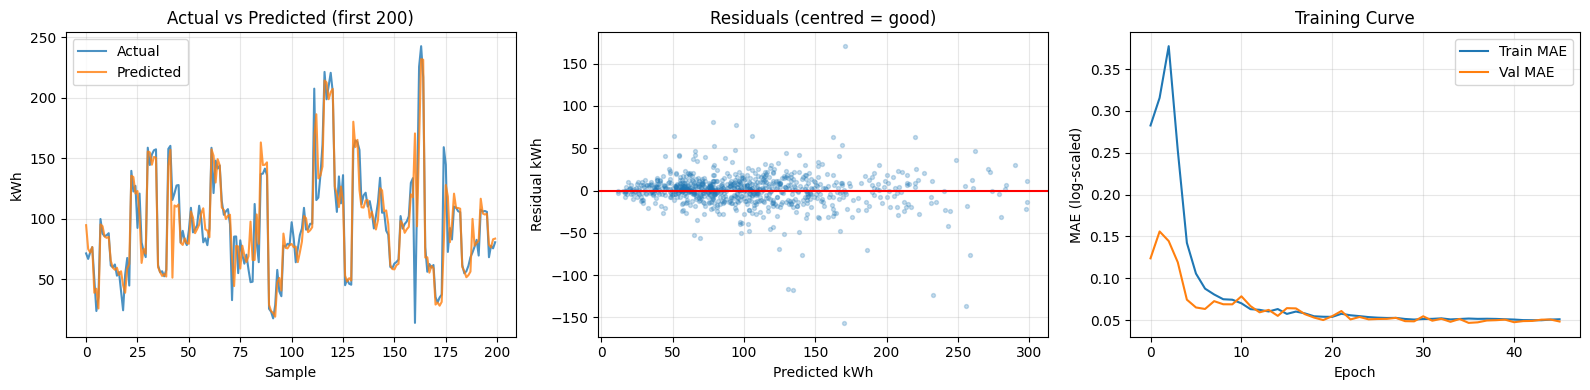

Plots saved.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

n = min(200, len(y_true_kwh))
axes[0].plot(y_true_kwh[:n], label='Actual',    linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_kwh[:n], label='Predicted', linewidth=1.5, alpha=0.8)
axes[0].set_title('Actual vs Predicted (first 200)')
axes[0].set_xlabel('Sample'); axes[0].set_ylabel('kWh')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

residuals = y_true_kwh - y_pred_kwh
axes[1].scatter(y_pred_kwh, residuals, alpha=0.25, s=8)
axes[1].axhline(0, color='red', linewidth=1.5)
axes[1].set_title('Residuals (centred = good)')
axes[1].set_xlabel('Predicted kWh'); axes[1].set_ylabel('Residual kWh')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['mae'],     label='Train MAE')
axes[2].plot(history.history['val_mae'], label='Val MAE')
axes[2].set_title('Training Curve')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MAE (log-scaled)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/LSTM/evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plots saved.')

In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# -----------------------------------
# BASELINE PREDICTION (HYBRID MODEL)
# -----------------------------------
y_pred = y_pred_kwh.copy()
y_true = y_true_kwh.copy()

baseline_mae = mean_absolute_error(y_true, y_pred)
print('Baseline MAE:', round(baseline_mae, 4))

# -----------------------------------
# PERMUTATION IMPORTANCE
# -----------------------------------
importance_results = []

# TIME FEATURES
for i, fname in enumerate(TIME_FEATURES):
    scores = []

    for _ in range(5):
        X_perm = Xte.copy()

        for t in range(X_perm.shape[1]):
            shuffled = X_perm[:, t, i].copy()
            np.random.shuffle(shuffled)
            X_perm[:, t, i] = shuffled

        y_perm_s = model.predict([X_perm, Bte], verbose=0).flatten()
        y_perm_model = scaler_y.inverse_transform(y_perm_s.reshape(-1, 1)).flatten()
        y_perm_naive = scaler_x.inverse_transform(Xte[:, -1, 0].reshape(-1, 1)).flatten()
        y_perm = apply_product_calibration(y_perm_model, y_perm_naive)

        mae_perm = mean_absolute_error(y_true, y_perm)
        scores.append(mae_perm - baseline_mae)

    importance_results.append((fname, float(np.mean(scores))))

# BEHAVIOR FEATURES
for i, fname in enumerate(BEHAVIOR_FEATURES):
    scores = []

    for _ in range(5):
        B_perm = Bte.copy()
        shuffled = B_perm[:, i].copy()
        np.random.shuffle(shuffled)
        B_perm[:, i] = shuffled

        y_perm_s = model.predict([Xte, B_perm], verbose=0).flatten()
        y_perm_model = scaler_y.inverse_transform(y_perm_s.reshape(-1, 1)).flatten()
        y_perm_naive = scaler_x.inverse_transform(Xte[:, -1, 0].reshape(-1, 1)).flatten()
        y_perm = apply_product_calibration(y_perm_model, y_perm_naive)

        mae_perm = mean_absolute_error(y_true, y_perm)
        scores.append(mae_perm - baseline_mae)

    importance_results.append((fname, float(np.mean(scores))))

# -----------------------------------
# SORT & DISPLAY
# -----------------------------------
importance_df = pd.DataFrame(importance_results, columns=['feature', 'importance'])
importance_df = importance_df.sort_values(by='importance', ascending=False)

print('\nTop Feature Importances (MAE increase):\n')
print(importance_df.head(20))

# Optional save
importance_df.to_csv('feature_importance.csv', index=False)

Baseline MAE: 12.4617

Top Feature Importances (MAE increase):

            feature  importance
0       monthly_kwh    2.777814
7  energy_intensity    1.007545
4             lag_3    0.394463
1             month    0.294861
2             lag_1    0.226153
5          ac_usage    0.029820
8       ac_fraction    0.027996
6        wfh_impact    0.008004
3             lag_2   -0.098574


## 11. K-Means Behavioral Clustering

One profile per household (mean across all their months).
Clustering on behavioral features only — no weather, no seasonal, no prev kWh.
The K-Means labels show WHICH GROUP a new household belongs to,
and drive personalized recommendations.

In [22]:
CLUSTER_FEATURES = ['family_size', 'avg_hours_wfh']
for col in ['ac_usage', 'energy_intensity', 'has_ac', 'ac_hours_per_day']:
    if col in df1.columns:
        CLUSTER_FEATURES.append(col)

# One row per household — mean across months
hh_profile = (df1.groupby('household_id')[CLUSTER_FEATURES]
                  .mean().fillna(0).reset_index())

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(hh_profile[CLUSTER_FEATURES])

print(f'Clustering {len(hh_profile)} households')
print(f'Cluster features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}')

Clustering 1287 households
Cluster features (6): ['family_size', 'avg_hours_wfh', 'ac_usage', 'energy_intensity', 'has_ac', 'ac_hours_per_day']


  K=2: silhouette=0.7888  inertia=6043
  K=3: silhouette=0.4394  inertia=4803
  K=4: silhouette=0.3399  inertia=3826
  K=5: silhouette=0.3709  inertia=3084
  K=6: silhouette=0.3771  inertia=2606
  K=7: silhouette=0.3795  inertia=2173
  K=8: silhouette=0.3878  inertia=1935


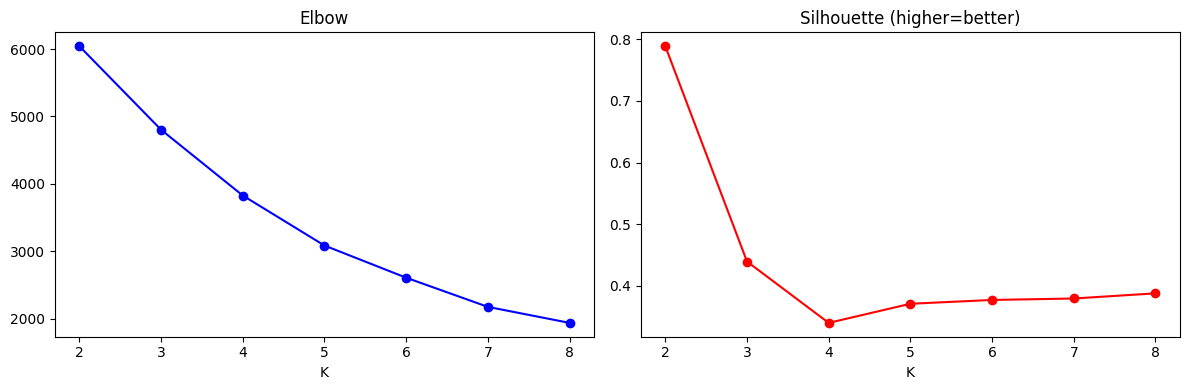

In [23]:
# Elbow + Silhouette
inertias, silhouettes = [], []
for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init=15)
    lbl = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, lbl,
                           sample_size=min(3000, len(X_cluster)), random_state=42)
    silhouettes.append(sil)
    print(f'  K={k}: silhouette={sil:.4f}  inertia={km.inertia_:.0f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(2,9), inertias,   'bo-'); ax[0].set_title('Elbow'); ax[0].set_xlabel('K')
ax[1].plot(range(2,9), silhouettes,'ro-'); ax[1].set_title('Silhouette (higher=better)')
ax[1].set_xlabel('K')
plt.tight_layout(); plt.show()

In [24]:
print(hh_profile.columns)

Index(['household_id', 'family_size', 'avg_hours_wfh', 'ac_usage',
       'energy_intensity', 'has_ac', 'ac_hours_per_day'],
      dtype='object')


In [25]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
hh_profile['cluster'] = kmeans.fit_predict(X_cluster)

final_sil = silhouette_score(X_cluster, hh_profile['cluster'],
                              sample_size=min(3000, len(X_cluster)), random_state=42)
print(f'Final silhouette (K={K}): {final_sil:.4f}')
print()

# Auto-label clusters by mean kWh (low → high)
df_c = df1.merge(hh_profile[['household_id','cluster']], on='household_id')
kwh_rank = df_c.groupby('cluster')['monthly_kwh'].mean().sort_values()

CLUSTER_LABELS = {
    int(kwh_rank.index[0]): 'Efficient',
    int(kwh_rank.index[1]): 'Moderate',
    int(kwh_rank.index[2]): 'High Usage',
}

print('Cluster profiles:')
for c, name in CLUSTER_LABELS.items():
    n_hh = (hh_profile['cluster'] == c).sum()
    kwh  = kwh_rank[c]
    print(f'  {name:<18}: {n_hh:4d} hh  mean={kwh:.0f} kWh ')

Final silhouette (K=3): 0.4402

Cluster profiles:
  Efficient         : 1084 hh  mean=104 kWh 
  Moderate          :  191 hh  mean=135 kWh 
  High Usage        :   12 hh  mean=167 kWh 


## 12. Bill Calculator — All 6 CEB 2024 Slabs

In [26]:
def calculate_bill(kwh: float) -> dict:
    """CEB 2024 domestic tariff. Returns total and per-slab breakdown."""
    kwh = max(0.0, float(kwh))
    SLABS = [
        (30,            8.00,  '0-30 units'),
        (60,           10.00,  '31-60 units'),
        (90,           16.00,  '61-90 units'),
        (120,          25.00,  '91-120 units'),
        (180,          45.00,  '121-180 units'),
        (float('inf'), 75.00,  '181+ units'),
    ]
    total, breakdown, remaining, prev = 0.0, [], kwh, 0
    for limit, rate, label in SLABS:
        if remaining <= 0: break
        units  = min(remaining, limit - prev)
        charge = units * rate
        total += charge
        breakdown.append({'slab': label, 'units': round(units, 2),
                          'rate_lkr_per_unit': rate,
                          'charge_lkr': round(charge, 2)})
        remaining -= units
        prev = limit
    return {'total_lkr': round(total, 2), 'slab_breakdown': breakdown}

# Verify
print('Bill verification:')
for kwh in [30, 90, 180, 250, 400, 600]:
    b = calculate_bill(kwh)
    print(f'  {kwh:4d} kWh → LKR {b["total_lkr"]:,.0f}')

Bill verification:
    30 kWh → LKR 240
    90 kWh → LKR 1,020
   180 kWh → LKR 4,470
   250 kWh → LKR 9,720
   400 kWh → LKR 20,970
   600 kWh → LKR 35,970


## 13. Full Prediction Pipeline

In [27]:
def predict_next_month_consumption(last_sequence: np.ndarray, behavior_vector: np.ndarray) -> float:
    """Predict next-month kWh from time sequence + behavior vector."""
    seq = np.asarray(last_sequence, dtype=np.float32)
    beh = np.asarray(behavior_vector, dtype=np.float32)

    if seq.shape != (SEQ_LEN, len(TIME_FEATURES)):
        raise ValueError(
            f'Expected sequence shape {(SEQ_LEN, len(TIME_FEATURES))}, got {seq.shape}'
        )
    if beh.shape != (len(BEHAVIOR_FEATURES),):
        raise ValueError(
            f'Expected behavior shape {(len(BEHAVIOR_FEATURES),)}, got {beh.shape}'
        )

    seq_scaled = seq.copy()
    for idx in TIME_SCALE_FEATURE_IDXS:
        seq_scaled[:, idx] = scaler_x.transform(seq[:, idx].reshape(-1, 1)).ravel()
    seq_scaled = apply_time_feature_weights(seq_scaled[np.newaxis, ...])[0]

    beh_scaled = scaler_b.transform(beh.reshape(1, -1)).astype(np.float32)

    pred_scaled = model.predict([seq_scaled[np.newaxis, ...], beh_scaled], verbose=0)
    model_kwh = float(scaler_y.inverse_transform(pred_scaled)[0, 0])
    naive_kwh = float(seq[-1, 0])
    pred_kwh = apply_product_calibration(np.array([model_kwh]), np.array([naive_kwh]))[0]
    return float(pred_kwh)

# Example: predict the next month for the last household in the dataset
example_hh = df1['household_id'].iloc[-1]
g = df1[df1['household_id'] == example_hh].sort_values('month')

last_sequence = g[TIME_FEATURES].tail(SEQ_LEN).to_numpy(dtype=np.float32)
last_behavior = g[BEHAVIOR_FEATURES].iloc[-1].to_numpy(dtype=np.float32)

if len(last_sequence) == SEQ_LEN:
    next_month_pred = predict_next_month_consumption(last_sequence, last_behavior)
    print(f'Example household: {example_hh}')
    print(f'Predicted next month kWh: {next_month_pred:.2f}')
else:
    print('Not enough history for example prediction.')

Example household: ID3822
Predicted next month kWh: 147.94


## 14. Test Prediction on a Real Household

In [28]:
# =========================================
# TEST PREDICTION ON REAL TEST SEQUENCES
# =========================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

sample_count = min(5, len(Xte))
sample_indices = rng.choice(len(Xte), size=sample_count, replace=False)

hh_test = hh_seq[te]
y_true_test = yte

results = []

for idx in sample_indices:
    hh = hh_test[idx]

    seq_raw = Xte_time_raw[idx].copy()
    beh_raw = scaler_b.inverse_transform(Bte[idx:idx+1])[0]
    pred_kwh = predict_next_month_consumption(seq_raw, beh_raw)
    true_kwh = float(y_true_test[idx])

    results.append({
        'household': hh,
        'true_kwh': round(true_kwh, 2),
        'pred_kwh': round(pred_kwh, 2),
        'error': round(abs(pred_kwh - true_kwh), 2),
    })

results_df = pd.DataFrame(results).sort_values('error')
results_df

,household,true_kwh,pred_kwh,error
2,ID2811,126.87,128.36,1.49
0,ID3150,56.80,50.49,6.31
1,ID2188,34.37,49.20,14.84
4,ID2133,121.72,105.50,16.22
3,ID0645,85.23,40.84,44.39


## 15. Save All Artifacts

In [29]:
# Save LSTM artifacts for the hybrid model
joblib.dump(scaler_x, '../models/LSTM/scaler_x.pkl')
joblib.dump(scaler_b, '../models/LSTM/scaler_b.pkl')
joblib.dump(scaler_y, '../models/LSTM/scaler_y.pkl')

# Save calibration parameters used by production inference
calibration_meta = {
    'blend_alpha': float(BLEND_ALPHA),
    'blend_scale': float(BLEND_SCALE),
    'blend_bias_kwh': float(BLEND_BIAS_KWH),
    'tier_edges': [float(x) for x in VAL_TIER_EDGES.tolist()],
    'tier_biases': [float(x) for x in VAL_TIER_BIASES.tolist()],
}
with open('../models/LSTM/calibration_meta.json', 'w') as f:
    json.dump(calibration_meta, f, indent=2)

# Save K-Means artifacts
joblib.dump(kmeans, '../models/K-means/kmeans_model.pkl')
joblib.dump(scaler_cluster, '../models/K-means/scaler_cluster.pkl')

# Save cluster metadata
cluster_meta = {
    'cluster_labels': {int(k): v for k, v in CLUSTER_LABELS.items()},
    'cluster_features': CLUSTER_FEATURES,
    'n_clusters': K,
    'silhouette_score': round(float(final_sil), 4),
}
with open('../models/K-means/cluster_meta.json', 'w') as f:
    json.dump(cluster_meta, f, indent=2)

meta = {
    'time_features': TIME_FEATURES,
    'behavior_features': BEHAVIOR_FEATURES,
    'seq_len': SEQ_LEN,
    'n_time_features': len(TIME_FEATURES),
    'n_behavior_features': len(BEHAVIOR_FEATURES),
    'calibration': calibration_meta,
    'metrics': {
        'mae_kwh': round(float(mae), 2),
        'rmse_kwh': round(float(rmse), 2),
        'wmape_pct': round(float(wmape), 2),
        'r2': round(float(r2), 4),
    }
}
with open('../models/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('All artifacts saved:')
print('LSTM models:')
for p in sorted(Path('../models/LSTM').rglob('*')):
    if p.is_file():
        size = p.stat().st_size / 1024
        print(f'  {p}  ({size:.1f} KB)')
print()
print('K-Means models:')
for p in sorted(Path('../models/K-means').rglob('*')):
    if p.is_file():
        size = p.stat().st_size / 1024
        print(f'  {p}  ({size:.1f} KB)')

All artifacts saved:
LSTM models:
  ../models/LSTM/calibration_meta.json  (0.3 KB)
  ../models/LSTM/evaluation_plots.png  (149.5 KB)
  ../models/LSTM/lstm_model.keras  (93.9 KB)
  ../models/LSTM/scaler_b.pkl  (0.7 KB)
  ../models/LSTM/scaler_x.pkl  (0.7 KB)
  ../models/LSTM/scaler_y.pkl  (0.7 KB)

K-Means models:
  ../models/K-means/cluster_meta.json  (0.3 KB)
  ../models/K-means/kmeans_model.pkl  (5.9 KB)
  ../models/K-means/scaler_cluster.pkl  (1.1 KB)


## 16. Final Summary

In [30]:
print('=' * 55)
print('         HYBRID LSTM + K-MEANS — FINAL RESULTS')
print('=' * 55)
print(f'  MAE   (kWh):    {mae:.2f}   {"✓ PASS" if mae  < 20 else "✗ FAIL"}  target < 20')
print(f'  RMSE  (kWh):    {rmse:.2f}   {"✓ PASS" if rmse < 30 else "✗ FAIL"}  target < 30')
print(f'  WMAPE (%):      {wmape:.1f}%   {"✓ PASS" if wmape < 15 else "✗ FAIL"}  target < 15%')
print(f'  R² Score:       {r2:.4f}   {"✓ PASS" if r2 > 0.85 else "✗ FAIL"}  target > 0.85')
print(f'  Silhouette:     {final_sil:.4f}')
print()
print('  predict.py pipeline:')
print('    input → scaler_x (MinMax time) + scaler_b (Standard behavior)')
print('    → LSTM(time) + Dense(behavior) → concat → scaler_y.inverse')
print('    → blend with naive(last month kWh) + bias calibration → kWh')
print('    → calculate_bill() → cluster assignment')
print('')

         HYBRID LSTM + K-MEANS — FINAL RESULTS
  MAE   (kWh):    12.46   ✓ PASS  target < 20
  RMSE  (kWh):    20.48   ✓ PASS  target < 30
  WMAPE (%):      12.1%   ✓ PASS  target < 15%
  R² Score:       0.8704   ✓ PASS  target > 0.85
  Silhouette:     0.4402

  predict.py pipeline:
    input → scaler_x (MinMax time) + scaler_b (Standard behavior)
    → LSTM(time) + Dense(behavior) → concat → scaler_y.inverse
    → blend with naive(last month kWh) + bias calibration → kWh
    → calculate_bill() → cluster assignment

